# Meta Policy Strategy Training

This notebook trains the top-level meta policy whose action is the selected strategy.

It chooses among the three pretrained low-level strategy policies:

- `lr_calculation`
- `lr_heuristic`
- `dt_traversal`

The meta-policy always has the same action space, `Discrete(3)`, but actions are anonymous slots rather than fixed strategy IDs. At the start of each episode, the three low-level strategies are randomly assigned to slots `0..2`; this assignment stays fixed within the episode. In `mixed` mode, each episode randomly samples one of `linear_regression`, `decision_tree`, or `hybrid`, but knowing the condition alone no longer reveals which slot corresponds to a preferred strategy.

New models use `MaskablePPO`: slots whose underlying strategy is unavailable in the episode condition are masked out. In the LR condition, the policy sees two legal anonymous slots without learning which is calculation or heuristic; in the DT-only condition there is necessarily just one legal action.

## Conditions

- `linear_regression`: the anonymous slots containing `lr_calculation` and `lr_heuristic` are legal; the DT slot is masked.
- `decision_tree`: only the anonymous slot containing `dt_traversal` is legal.
- `hybrid`: all three strategies are available. On each trial, either no explanation, an LR explanation, or a DT explanation is shown. If the chosen strategy's own explanation is not shown, its low-level policy cannot read that explanation and must behave as a retrieval/memory-based strategy.

The hybrid condition fixes complexity per episode: low complexity uses sparse LR and depth-2 DT explanations; high complexity uses dense LR and depth-3 DT explanations.

## Observation Space

The combined observation has 43 dimensions in the default configuration (`history_window=5`):

1. mean probability-correct for each anonymous strategy slot over the previous five occurrences of each explanation type (`none`, `lr`, `dt`): `9`
2. mean prediction-time for each anonymous strategy slot over the previous five occurrences of each explanation type (`none`, `lr`, `dt`): `9`
3. previous five selected anonymous slots, each encoded as a three-way one-hot slot: `15`
4. normalized cognitive parameters: decision noise, memory retrieval threshold, opportunity cost: `3`
5. episode condition one-hot: `linear_regression`, `decision_tree`, `hybrid`: `3`
6. current explanation one-hot: `none`, `lr`, `dt`: `3`
7. episode progress: `1`

The history summaries are arranged slot-major: the three explanation buckets for slot `0`, followed by slot `1`, followed by slot `2`. Strategy-to-slot identity is deliberately absent from the observation. `selected_strategy` and `strategy_slot_order` are emitted only in evaluation `info` for analysis.

Older saved meta-policy models cannot be reused here: fixed-slot PPO checkpoints reveal strategy identity, and earlier masked-slot checkpoints do not have the explanation-conditioned history dimensions.


In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "rl_agents":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('c:/Users/Louth/Desktop/xaikit-test stage 3/CoXAM')

In [2]:
from rl_agents.meta_policy_strategy import (
    CONDITIONS,
    META_STRATEGIES,
    CombinedPolicyConfig,
    combined_observation_action_summary,
    default_combined_parameter_sweep_values,
    evaluate_combined_policy,
    load_combined_bundles,
    load_combined_policy,
    plot_combined_parameter_sweep,
    plot_meta_strategy_selection_by_dataset,
    summarize_combined_evaluation,
    summarize_combined_parameter_sweep,
    summarize_meta_strategy_selection_by_dataset,
    sweep_combined_parameters,
    train_combined_policy,
)


In [3]:
# Point this at the output folder produced by individual_policy_training_f.ipynb.
LOW_LEVEL_RUN = ROOT / "outputs" / "unified_strategy_policy" / "unified_strategy_demo"

combined_config = CombinedPolicyConfig(
    data_dir=str(ROOT / "datasets"),
    output_root=str(ROOT / "outputs" / "combined_strategy_meta_policy"),
    run_name="meta_policy_strategy_masked_explanation_history_demo",
    condition_name="mixed",
    total_timesteps=6e5,
    n_envs=4,
    instances_per_episode=40,
    max_features=6,
    explanation_shown_ratio=0.5,
    history_window=5,
    simulation_sample_count=16,
    memory_recall_threshold_min=-5.0,
    unavailable_strategy_penalty=-1.0,
    randomize_strategy_order_per_episode=True,
    meta_history_by_explanation=True,
    apps=None,
    lr_calculation_model_path=str(LOW_LEVEL_RUN / "lr_calculation" / "models" / "final_model.zip"),
    lr_heuristic_model_path=str(LOW_LEVEL_RUN / "lr_heuristic" / "models" / "final_model.zip"),
    dt_traversal_model_path=str(LOW_LEVEL_RUN / "dt_traversal" / "models" / "final_model.zip"),
)

asdict(combined_config)

{'data_dir': 'c:\\Users\\Louth\\Desktop\\xaikit-test stage 3\\CoXAM\\datasets',
 'output_root': 'c:\\Users\\Louth\\Desktop\\xaikit-test stage 3\\CoXAM\\outputs\\combined_strategy_meta_policy',
 'run_name': 'meta_policy_strategy_masked_explanation_history_demo',
 'condition_name': 'mixed',
 'total_timesteps': 600000.0,
 'n_envs': 4,
 'instances_per_episode': 40,
 'max_features': 6,
 'explanation_shown_ratio': 0.5,
 'seed': 123,
 'learning_rate': 0.0003,
 'gamma': 0.85,
 'ent_coef': 0.01,
 'n_steps': 512,
 'batch_size': 256,
 'decision_boundary_bins': 5,
 'decision_boundary_min': 0.6,
 'decision_boundary_max': 1.8,
 'decision_noise_min': 0.3,
 'decision_noise_max': 0.7,
 'memory_recall_threshold_min': -1.0,
 'memory_recall_threshold_max': 2.0,
 'opportunity_cost_min': 0.0,
 'opportunity_cost_max': 0.02,
 'memory_recall_noise': 0.5,
 'retrieval_candidate_count': 3,
 'simulation_sample_count': 16,
 'read_seconds_per_item': 1.0,
 'mental_calculation_seconds': 0.0,
 'displayed_significant_fi

In [4]:
combined_observation_action_summary(combined_config)

,condition_name,observation_space,observation_contents,action_space,action_contents
0,linear_regression,"Box(43, low=-1, high=1)","slot-major per anonymous strategy slot, mean p...",Discrete(3),0..2 select anonymous strategy slots shuffled ...
1,decision_tree,"Box(43, low=-1, high=1)","slot-major per anonymous strategy slot, mean p...",Discrete(3),0..2 select anonymous strategy slots shuffled ...
2,hybrid,"Box(43, low=-1, high=1)","slot-major per anonymous strategy slot, mean p...",Discrete(3),0..2 select anonymous strategy slots shuffled ...
3,mixed,"Box(43, low=-1, high=1)","slot-major per anonymous strategy slot, mean p...",Discrete(3),0..2 select anonymous strategy slots shuffled ...


In [5]:
bundles = load_combined_bundles(ROOT / "datasets", combined_config)
pd.DataFrame([
    {
        "app_id": bundle.app_id,
        "model_name": bundle.model_name,
        "instances": len(bundle.instance_ids),
    }
    for bundle in bundles
])

Skipping german_credit/xgboost: No logistic regression explanation found for appId: german_credit and variant: dense
Skipping diabetes/xgboost: No logistic regression explanation found for appId: diabetes and variant: dense


,app_id,model_name,instances
0,adult,xgboost,120
1,forest_cover,xgboost,120
2,wine_quality,mlp,400
3,mushrooms,mlp,400
4,adult,mlp,400
5,forest_cover,mlp,400
6,breast_cancer,mlp,400
7,breast_cancer,xgboost,400
8,wine_binary,mlp,130
9,wine_binary,xgboost,130


In [6]:
for strategy_name, model_path in {
    "lr_calculation": combined_config.lr_calculation_model_path,
    "lr_heuristic": combined_config.lr_heuristic_model_path,
    "dt_traversal": combined_config.dt_traversal_model_path,
}.items():
    path = Path(model_path)
    print(f"{strategy_name}: {path} exists={path.exists()}")

lr_calculation: c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\lr_calculation\models\final_model.zip exists=True
lr_heuristic: c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\lr_heuristic\models\final_model.zip exists=True
dt_traversal: c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\dt_traversal\models\final_model.zip exists=True


## Train Mixed-Condition Model

This trains one shared masked meta-policy. Each episode randomly uses `linear_regression`, `decision_tree`, or `hybrid`; it also reshuffles the anonymous strategy slots. Correctness and timing summaries keep the last five observations separately for each shown explanation type and remain arranged by anonymous slot, so selecting action slot `i` can be learned from the history features for slot `i` without revealing its strategy identity. Train a fresh model because earlier checkpoints have a different observation contract.

In [7]:
# Keep this False after adding explanation-conditioned slot histories; older models are incompatible.
REUSE_SAVED_MODEL = False
COMBINED_MODEL_PATH = None  # Optional explicit path to final_model.zip

if REUSE_SAVED_MODEL:
    model, run_dir, trained_bundles = load_combined_policy(
        combined_config,
        model_path=COMBINED_MODEL_PATH,
    )
else:
    model, run_dir, trained_bundles = train_combined_policy(combined_config)

run_dir


Skipping german_credit/xgboost: No logistic regression explanation found for appId: german_credit and variant: dense
Skipping diabetes/xgboost: No logistic regression explanation found for appId: diabetes and variant: dense
Using cpu device
Eval num_timesteps=2048, episode_reward=22.06 +/- 3.69
Episode length: 40.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 40       |
|    mean_reward     | 22.1     |
| time/              |          |
|    total_timesteps | 2048     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 21.1     |
| time/              |          |
|    fps             | 120      |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 2048     |
---------------------------------
Eval num_timesteps=4096, episode_reward=17.07 +/- 2.46
Episode length: 40

WindowsPath('c:/Users/Louth/Desktop/xaikit-test stage 3/CoXAM/outputs/combined_strategy_meta_policy/meta_policy_strategy_masked_explanation_history_demo/mixed')

## Optional Single-Condition Training

Use this only when you intentionally want a condition-specific baseline instead of the shared mixed-condition model.

In [8]:
single_condition_config = CombinedPolicyConfig(
    **{
        **asdict(combined_config),
        "condition_name": "hybrid",
        "run_name": "combined_strategy_meta_hybrid_only",
    }
)

# model, run_dir, trained_bundles = train_combined_policy(single_condition_config)
# run_dir

## Evaluate

The evaluation output includes the anonymous selected slot, its diagnostic `strategy_slot_order` mapping, the actual selected strategy, the explanation type shown, and the selected probability/time. The mapping is for analysis only; it is not part of the policy observation.

In [9]:
evaluation_df = evaluate_combined_policy(
    model,
    trained_bundles,
    combined_config,
    n_episodes=30,
    deterministic=True,
)
eval_path = run_dir / "metrics" / "evaluation.csv"
evaluation_df.to_csv(eval_path, index=False)
if not evaluation_df.empty:
    for (app_id, model_name), dataset_eval_df in evaluation_df.groupby(["app_id", "model_name"], dropna=False):
        print(f"\nSample rows: {app_id} / {model_name}")
        display(dataset_eval_df.head())



Sample rows: adult / xgboost


,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_prob_correct,selected_predicted_class,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask
560,14,0,decision_tree,mixed,high,adult,xgboost,dt,0,"[dt_traversal, lr_heuristic, lr_calculation]",...,0.3750,1,False,22.896984,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
561,14,1,decision_tree,mixed,high,adult,xgboost,dt,0,"[dt_traversal, lr_heuristic, lr_calculation]",...,0.0000,0,False,22.896984,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
562,14,2,decision_tree,mixed,high,adult,xgboost,dt,0,"[dt_traversal, lr_heuristic, lr_calculation]",...,0.5625,1,True,17.828276,0.9,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
563,14,3,decision_tree,mixed,high,adult,xgboost,dt,0,"[dt_traversal, lr_heuristic, lr_calculation]",...,0.8750,0,True,22.896984,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
564,14,4,decision_tree,mixed,high,adult,xgboost,dt,0,"[dt_traversal, lr_heuristic, lr_calculation]",...,0.1875,1,False,22.896984,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"



Sample rows: anes96_vote / mlp


,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_prob_correct,selected_predicted_class,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask
680,17,0,hybrid,mixed,high,anes96_vote,mlp,dt,1,"[lr_heuristic, lr_calculation, dt_traversal]",...,0.745919,0,True,3.015102,0.6,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
681,17,1,hybrid,mixed,high,anes96_vote,mlp,dt,1,"[lr_heuristic, lr_calculation, dt_traversal]",...,0.131122,0,False,2.802654,0.6,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
682,17,2,hybrid,mixed,high,anes96_vote,mlp,none,1,"[lr_heuristic, lr_calculation, dt_traversal]",...,0.038902,0,False,2.643317,0.6,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
683,17,3,hybrid,mixed,high,anes96_vote,mlp,lr,2,"[lr_heuristic, lr_calculation, dt_traversal]",...,0.500000,0,False,0.500000,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
684,17,4,hybrid,mixed,high,anes96_vote,mlp,none,1,"[lr_heuristic, lr_calculation, dt_traversal]",...,0.315561,0,False,10.621327,0.6,retrieve,"[0, 2, 1]","[0, 1, 2]","[1, 1, 1, 0, 0, 0]","[1, 1, 1, 0, 0, 0]"



Sample rows: breast_cancer / mlp


...

,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_prob_correct,selected_predicted_class,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask
520,13,0,decision_tree,mixed,low,wine_binary,mlp,dt,0,"[dt_traversal, lr_calculation, lr_heuristic]",...,1.0,1,True,15.931322,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
521,13,1,decision_tree,mixed,low,wine_binary,mlp,dt,0,"[dt_traversal, lr_calculation, lr_heuristic]",...,1.0,1,True,15.931322,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
522,13,2,decision_tree,mixed,low,wine_binary,mlp,dt,0,"[dt_traversal, lr_calculation, lr_heuristic]",...,1.0,1,True,12.552184,0.9,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
523,13,3,decision_tree,mixed,low,wine_binary,mlp,none,0,"[dt_traversal, lr_calculation, lr_heuristic]",...,0.5,0,False,0.593750,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
524,13,4,decision_tree,mixed,low,wine_binary,mlp,none,0,"[dt_traversal, lr_calculation, lr_heuristic]",...,0.5,0,False,2.866415,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"



Sample rows: wine_binary / xgboost


,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_prob_correct,selected_predicted_class,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask
0,0,0,decision_tree,mixed,low,wine_binary,xgboost,none,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,0.6250,1,True,9.432265,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
1,0,1,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,1.0000,1,True,15.931322,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
2,0,2,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,0.9375,1,True,12.552184,0.9,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
3,0,3,decision_tree,mixed,low,wine_binary,xgboost,none,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,0.5000,0,False,1.216604,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
4,0,4,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,1.0000,1,True,15.931322,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"



Sample rows: wine_quality / mlp


,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_prob_correct,selected_predicted_class,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask
280,7,0,hybrid,mixed,low,wine_quality,mlp,lr,1,"[lr_calculation, dt_traversal, lr_heuristic]",...,0.437500,1,False,8.486204,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
281,7,1,hybrid,mixed,low,wine_quality,mlp,lr,1,"[lr_calculation, dt_traversal, lr_heuristic]",...,0.468750,0,False,2.928915,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
282,7,2,hybrid,mixed,low,wine_quality,mlp,dt,1,"[lr_calculation, dt_traversal, lr_heuristic]",...,0.875000,0,True,15.931322,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
283,7,3,hybrid,mixed,low,wine_quality,mlp,dt,2,"[lr_calculation, dt_traversal, lr_heuristic]",...,0.361044,0,False,3.239891,0.6,heuristic,[0],[1],"[1, 0, 0, 0, 0, 0]","[0, 1, 0, 0, 0, 0]"
284,7,4,hybrid,mixed,low,wine_quality,mlp,none,1,"[lr_calculation, dt_traversal, lr_heuristic]",...,0.500000,0,True,1.052421,0.6,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"


In [10]:
evaluation_summary = summarize_combined_evaluation(evaluation_df)
if not evaluation_summary.empty:
    for (app_id, model_name), dataset_summary in evaluation_summary.groupby(["app_id", "model_name"], dropna=False):
        print(f"\n=== {app_id} / {model_name} ===")
        display(dataset_summary.drop(columns=["app_id", "model_name"]))



=== adult / xgboost ===


,condition_name,selected_strategy,selected_strategy_available,trials,mean_reward,mean_prob_correct,mean_time,condition_trials,selection_rate
0,decision_tree,dt_traversal,True,80,0.360384,0.470703,11.031906,80,1.0



=== anes96_vote / mlp ===


,condition_name,selected_strategy,selected_strategy_available,trials,mean_reward,mean_prob_correct,mean_time,condition_trials,selection_rate
1,hybrid,dt_traversal,True,1,0.495000,0.500000,0.500000,40,0.025
2,hybrid,lr_calculation,True,37,0.577096,0.631823,5.472646,40,0.925
3,hybrid,lr_heuristic,True,2,0.118348,0.152729,3.438141,40,0.050



=== breast_cancer / mlp ===


...

,condition_name,selected_strategy,selected_strategy_available,trials,mean_reward,mean_prob_correct,mean_time,condition_trials,selection_rate
32,decision_tree,dt_traversal,True,80,0.560034,0.659375,9.934083,80,1.0



=== wine_binary / xgboost ===


,condition_name,selected_strategy,selected_strategy_available,trials,mean_reward,mean_prob_correct,mean_time,condition_trials,selection_rate
33,decision_tree,dt_traversal,True,40,0.596163,0.707812,11.164926,40,1.0



=== wine_quality / mlp ===


,condition_name,selected_strategy,selected_strategy_available,trials,mean_reward,mean_prob_correct,mean_time,condition_trials,selection_rate
34,hybrid,dt_traversal,True,8,0.528143,0.597656,6.951340,40,0.200
35,hybrid,lr_calculation,True,13,0.568930,0.645682,7.675206,40,0.325
36,hybrid,lr_heuristic,True,19,0.561134,0.599295,3.816119,40,0.475
37,linear_regression,lr_calculation,True,40,0.505397,0.588872,8.347573,40,1.000


## Cognitive Parameter Sweep

This evaluates the trained mixed-condition meta-policy while clamping one cognitive parameter at a time. The output shows how often each strategy is selected as `decision_noise`, `memory_recall_threshold`, or `opportunity_cost` changes.


In [11]:
sweep_values = default_combined_parameter_sweep_values(combined_config, n_points=5)
sweep_values


{'decision_noise': [0.3, 0.4, 0.5, 0.6, 0.7],
 'memory_recall_threshold': [-1.0, -0.25, 0.5, 1.25, 2.0],
 'opportunity_cost': [0.0, 0.005, 0.01, 0.015, 0.02]}

In [12]:
combined_sweep_df = sweep_combined_parameters(
    model,
    trained_bundles,
    combined_config,
    sweep_values=sweep_values,
    n_episodes=20,
    deterministic=True,
)
combined_sweep_path = run_dir / "metrics" / "cognitive_parameter_sweep.csv"
combined_sweep_df.to_csv(combined_sweep_path, index=False)
combined_sweep_df.head()


,episode,step,condition_name,condition_mode,episode_complexity,app_id,model_name,explanation_type,selected_strategy_slot,strategy_slot_order,...,selected_predicted_correct,selected_pred_time,selected_decision_boundary,selected_mode,selected_features,selected_feature_slots,selected_feature_mask,selected_feature_slot_mask,sweep_parameter,sweep_value
0,0,0,decision_tree,mixed,low,wine_binary,xgboost,none,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,True,6.985185,0.6,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",decision_noise,0.3
1,0,1,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,True,15.676248,0.9,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",decision_noise,0.3
2,0,2,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,True,15.676248,0.9,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",decision_noise,0.3
3,0,3,decision_tree,mixed,low,wine_binary,xgboost,none,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,False,1.215146,1.2,retrieve,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",decision_noise,0.3
4,0,4,decision_tree,mixed,low,wine_binary,xgboost,dt,2,"[lr_calculation, lr_heuristic, dt_traversal]",...,True,18.884686,1.2,read,[],[],"[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]",decision_noise,0.3


In [13]:
selection_summary = summarize_combined_parameter_sweep(combined_sweep_df)
display(
    selection_summary.sort_values(["sweep_parameter", "condition_name", "sweep_value", "selected_strategy"])
)


,sweep_parameter,sweep_value,condition_name,selected_strategy,trials,mean_reward,mean_prob_correct,mean_time,availability_rate,condition_trials,selection_rate
2,decision_noise,0.300,decision_tree,dt_traversal,360,0.539678,0.634028,9.434928,1.0,360,1.000000
0,decision_noise,0.300,decision_tree,lr_calculation,0,0.000000,0.000000,0.000000,0.0,360,0.000000
1,decision_noise,0.300,decision_tree,lr_heuristic,0,0.000000,0.000000,0.000000,0.0,360,0.000000
11,decision_noise,0.400,decision_tree,dt_traversal,360,0.522017,0.619010,9.699359,1.0,360,1.000000
9,decision_noise,0.400,decision_tree,lr_calculation,0,0.000000,0.000000,0.000000,0.0,360,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
123,opportunity_cost,0.015,linear_regression,lr_calculation,2,0.351006,0.426002,4.999753,1.0,120,0.016667
124,opportunity_cost,0.015,linear_regression,lr_heuristic,118,0.507041,0.546954,2.660863,1.0,120,0.983333
134,opportunity_cost,0.020,linear_regression,dt_traversal,0,0.000000,0.000000,0.000000,0.0,120,0.000000
132,opportunity_cost,0.020,linear_regression,lr_calculation,2,0.460016,0.538281,3.913268,1.0,120,0.016667


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Louth\\Desktop\\xaikit-test stage 3\\CoXAM\\outputs\\combined_strategy_meta_policy\\meta_policy_strategy_masked_explanation_history_demo\\mixed\\metrics\\cognitive_parameter_sweep_plots\\combined_sweep_opportunity_cost_strategy_selection_by_dataset_decision_tree.png'

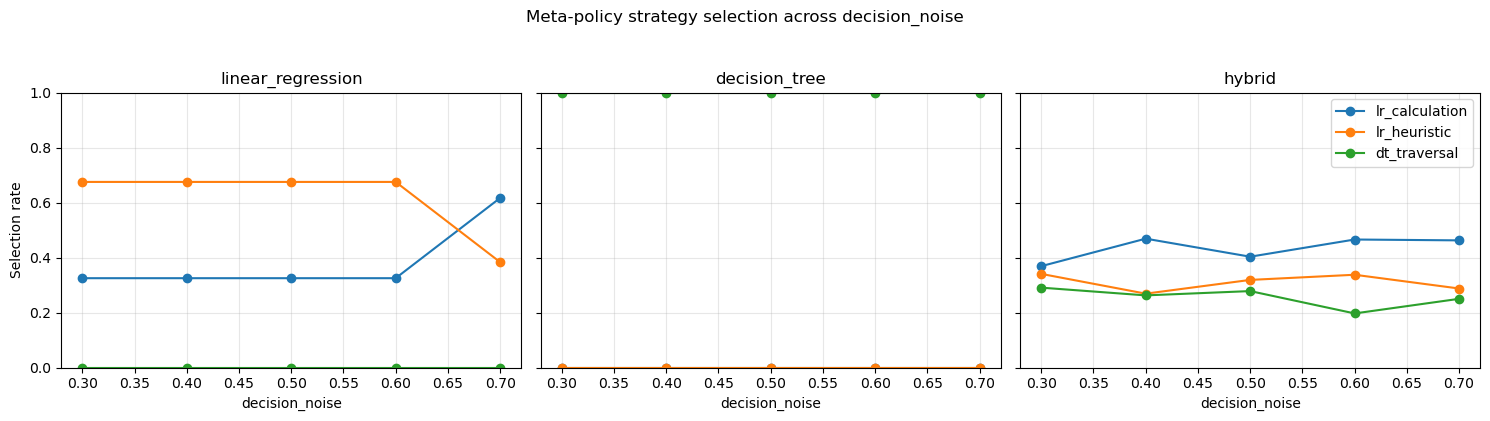

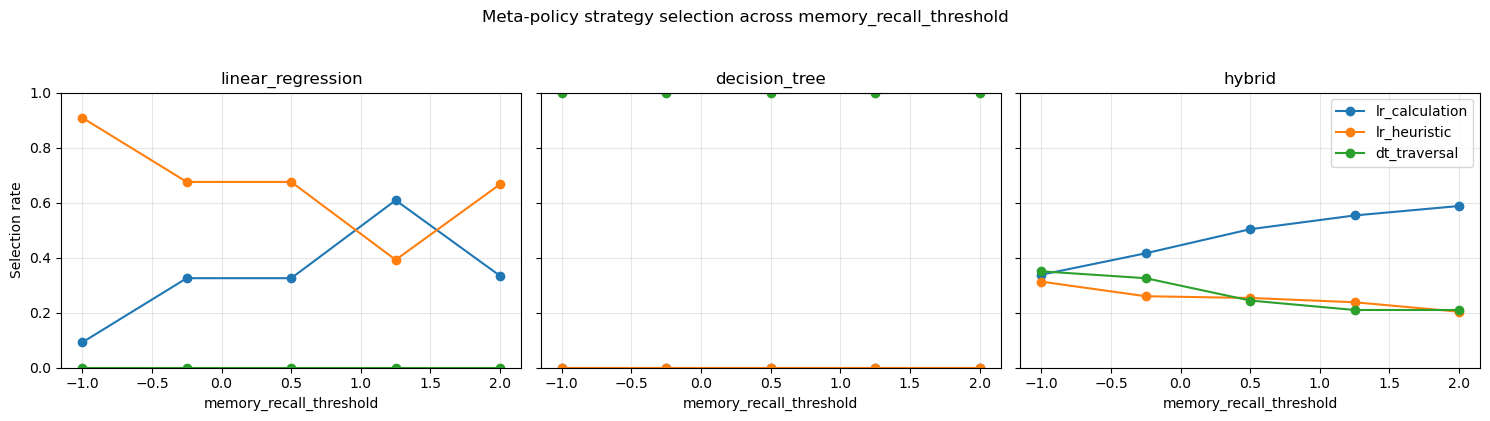

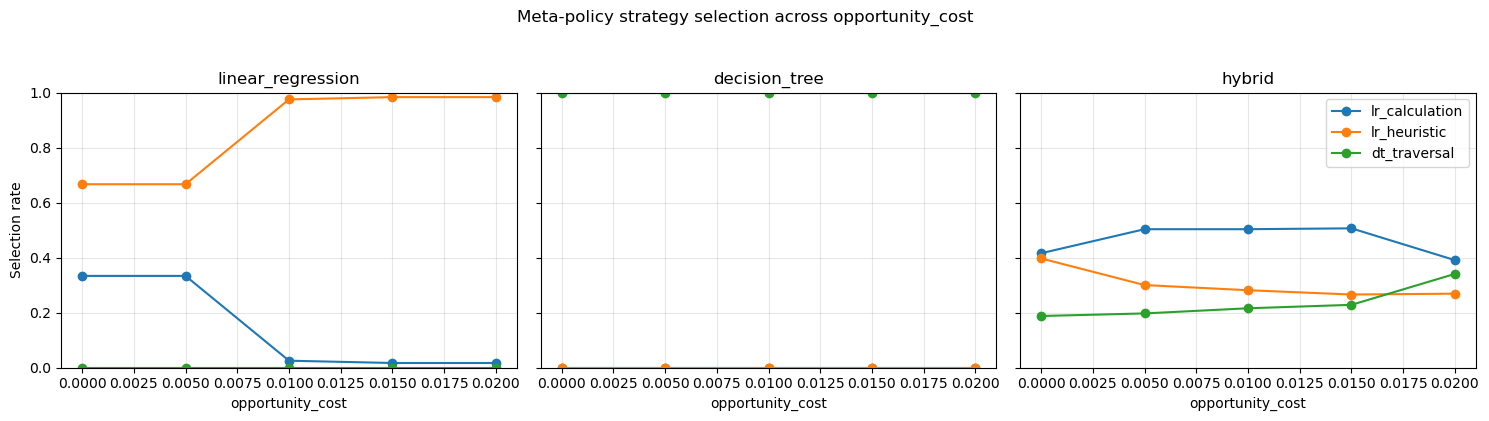

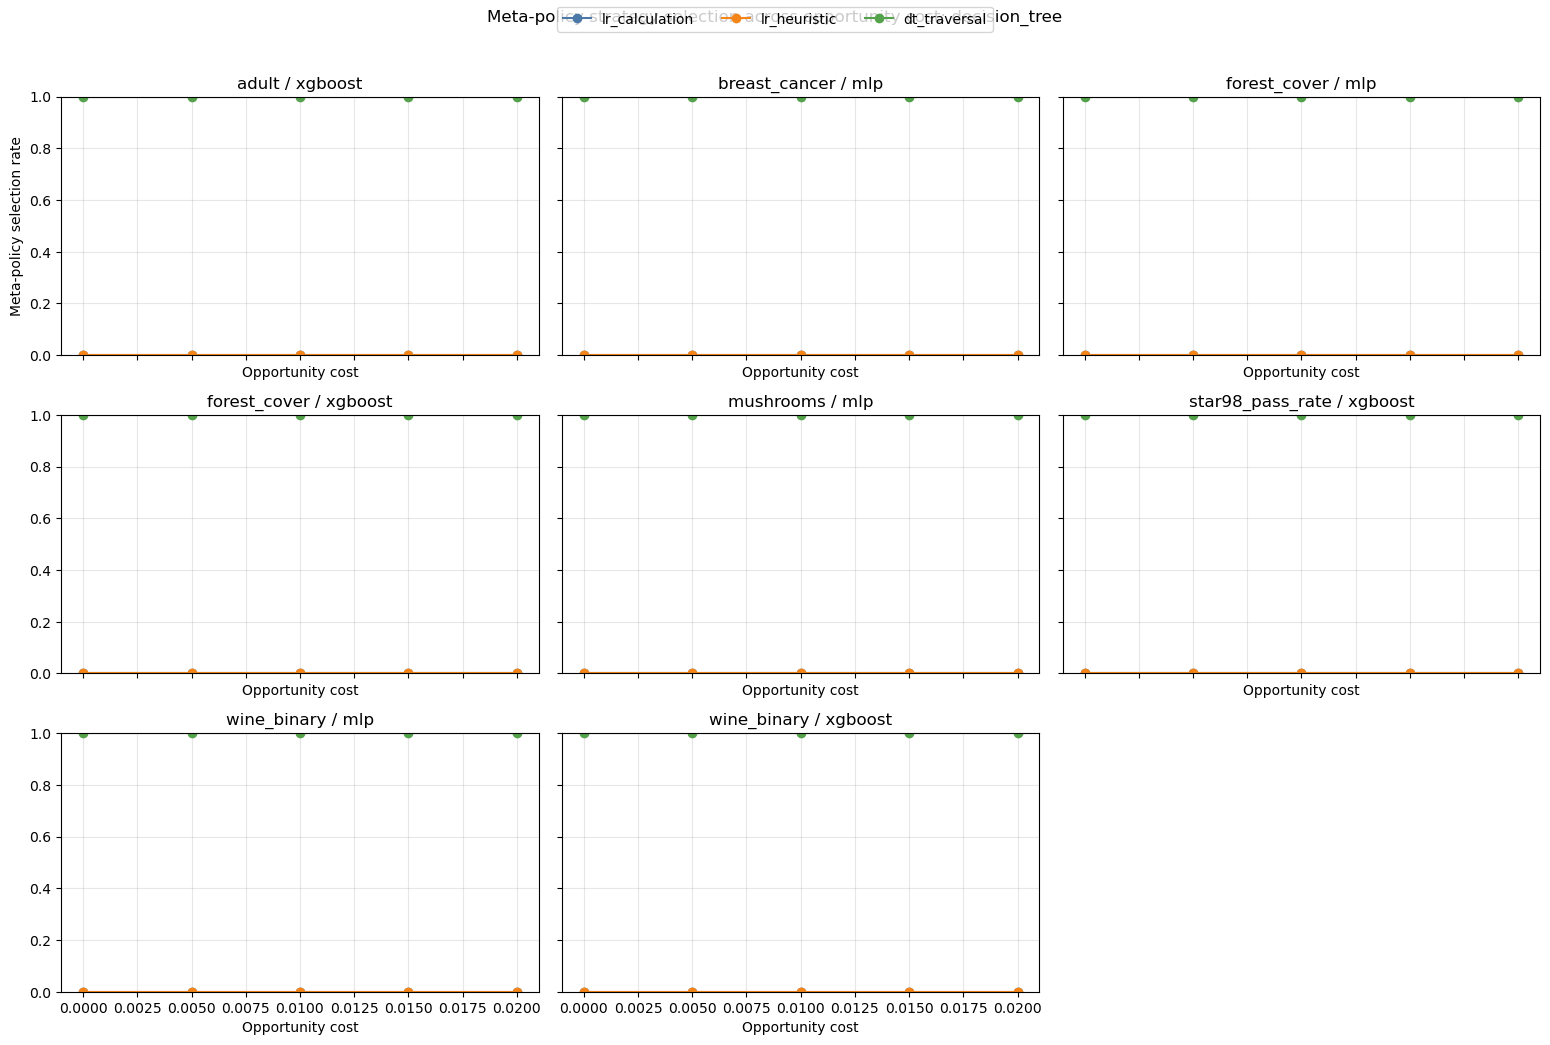

In [14]:
sweep_figures = plot_combined_parameter_sweep(
    combined_sweep_df,
    output_dir=run_dir / "metrics" / "cognitive_parameter_sweep_plots",
    show=True,
)

dataset_selection_summary = summarize_meta_strategy_selection_by_dataset(combined_sweep_df)
dataset_selection_summary.to_csv(
    run_dir / "metrics" / "meta_strategy_selection_by_dataset_opportunity_cost.csv",
    index=False,
)
dataset_selection_figures = plot_meta_strategy_selection_by_dataset(
    combined_sweep_df,
    output_dir=run_dir / "metrics" / "cognitive_parameter_sweep_plots",
    show=True,
)

display(dataset_selection_summary.head(30))
list(sweep_figures.keys()) + list(dataset_selection_figures.keys())
